In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"19bed4598ff7aab45cf59c4763d0f7f6"}'}

In [2]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [3]:
!pip install kaggle


In [4]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
  0% 0.00/40.4M [00:00<?, ?B/s]
100% 40.4M/40.4M [00:00<00:00, 1.66GB/s]


In [5]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [6]:
import os

for root, dirs, files in os.walk("CWRU_Dataset"):
    for file in files:
        if file.endswith(".mat") or file.endswith(".npz") or file.endswith(".csv"):
            print(os.path.join(root, file))


CWRU_Dataset/feature_time_48k_2048_load_1.csv
CWRU_Dataset/CWRU_48k_load_1_CNN_data.npz
CWRU_Dataset/raw/Time_Normal_1_098.mat
CWRU_Dataset/raw/OR021_6_1_239.mat
CWRU_Dataset/raw/IR014_1_175.mat
CWRU_Dataset/raw/IR007_1_110.mat
CWRU_Dataset/raw/IR021_1_214.mat
CWRU_Dataset/raw/OR007_6_1_136.mat
CWRU_Dataset/raw/B014_1_190.mat
CWRU_Dataset/raw/B007_1_123.mat
CWRU_Dataset/raw/OR014_6_1_202.mat
CWRU_Dataset/raw/B021_1_227.mat


In [7]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization


In [8]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files:", len(mat_files))


Total .mat files: 10


In [9]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)

    for key in mat_data.keys():
        if "DE_time" in key:
            return mat_data[key].flatten()

    raise ValueError(f"No DE_time signal found in {file_path}")


In [10]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"


In [11]:
def segment_signal(signal, segment_size=2048):
    segments = []
    for i in range(0, len(signal) - segment_size, segment_size):
        segments.append(signal[i:i+segment_size])
    return np.array(segments)


In [12]:
X = []
y = []

SEGMENT_SIZE = 2048

for file in mat_files:
    signal = extract_signal_from_mat(file)
    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal, SEGMENT_SIZE)

    for seg in segments:
        X.append(seg)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (samples, 2048)
print("y shape:", y.shape)
print("Classes:", np.unique(y))


X shape: (2369, 2048)
y shape: (2369,)
Classes: ['B' 'IR' 'Normal' 'OR']


In [13]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class labels:", label_encoder.classes_)


Class labels: ['B' 'IR' 'Normal' 'OR']


In [14]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("Reshaped X:", X.shape)


Reshaped X: (2369, 2048, 1)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (1895, 2048, 1)
Test : (474, 2048, 1)


In [16]:
print(label_encoder.classes_)


['B' 'IR' 'Normal' 'OR']


**Class Distribution Plot**

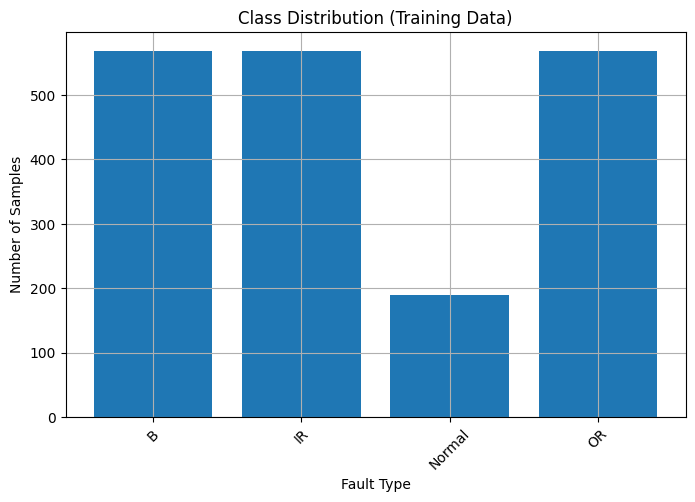

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

y_series = pd.Series(y_train)
class_counts = y_series.value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(label_encoder.classes_, class_counts.values)
plt.title("Class Distribution (Training Data)")
plt.xlabel("Fault Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Plot Raw Signal (Time Domain)

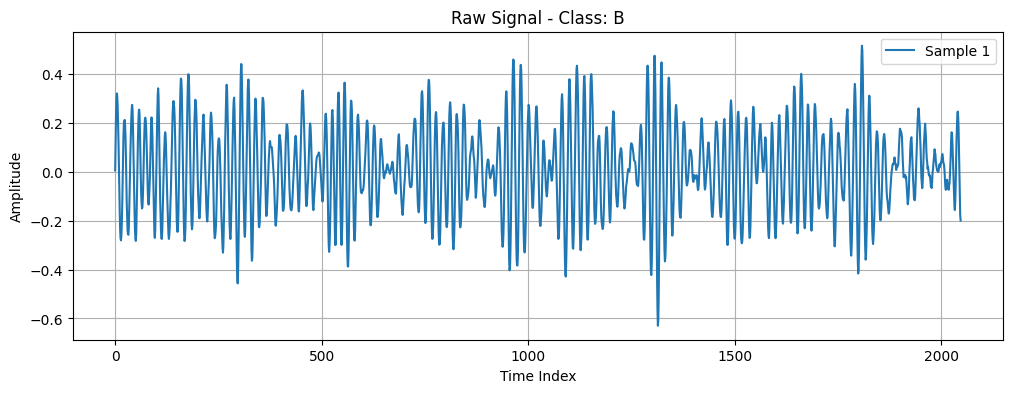

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_signal(X, y, class_id, num_samples=1):
    idx = np.where(y == class_id)[0]
    plt.figure(figsize=(12,4))

    for i in range(num_samples):
        plt.plot(X[idx[i]].flatten(), label=f"Sample {i+1}")

    plt.title(f"Raw Signal - Class: {label_encoder.classes_[class_id]}")
    plt.xlabel("Time Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: plot class 0 signal
plot_raw_signal(X_train, y_train, class_id=0, num_samples=1)


In [19]:
import os
print(os.listdir("/content/CWRU_Dataset/raw"))


['Time_Normal_1_098.mat', 'OR021_6_1_239.mat', 'IR014_1_175.mat', 'IR007_1_110.mat', 'IR021_1_214.mat', 'OR007_6_1_136.mat', 'B014_1_190.mat', 'B007_1_123.mat', 'OR014_6_1_202.mat', 'B021_1_227.mat']


In [20]:
import scipy.io as sio

file_path = "/content/CWRU_Dataset/raw/IR014_1_175.mat"
data = sio.loadmat(file_path)

print(data.keys())  # check keys

# automatically pick DE_time signal
for key in data.keys():
    if "DE_time" in key:
        signal = data[key]
        print("Signal key:", key)
        print("Signal shape:", signal.shape)
        print("Total samples:", len(signal))
        break


dict_keys(['__header__', '__version__', '__globals__', 'X217', 'X217_DE_time', 'X175_DE_time', 'X175_FE_time', 'X175RPM'])
Signal key: X217_DE_time
Signal shape: (489125, 1)
Total samples: 489125


In [21]:
segment_length = 2048
num_segments = 489125 // 2048
print(num_segments)


238


Finding Fault using Amplitude vs Frequency plots

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def compute_fft(signal, fs):

    N = len(signal)

    fft_vals = np.fft.fft(signal)
    fft_vals = np.abs(fft_vals) / N

    freqs = np.fft.fftfreq(N, 1/fs)

    mask = freqs >= 0

    return freqs[mask], fft_vals[mask]

In [23]:
def plot_fft_multi(class_name, fs, n_samples=5):

    class_id = np.where(label_encoder.classes_ == class_name)[0][0]

    idxs = np.where(y_train == class_id)[0][:n_samples]

    plt.figure(figsize=(8,4))

    for i in idxs:

        signal = X_train[i].flatten()

        freqs, amp = compute_fft(signal, fs)

        plt.plot(freqs, amp, alpha=0.5)

    plt.title(f"{class_name}  | fs={fs}")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")

    plt.xlim(0,300)

    plt.grid(True)
    plt.show()

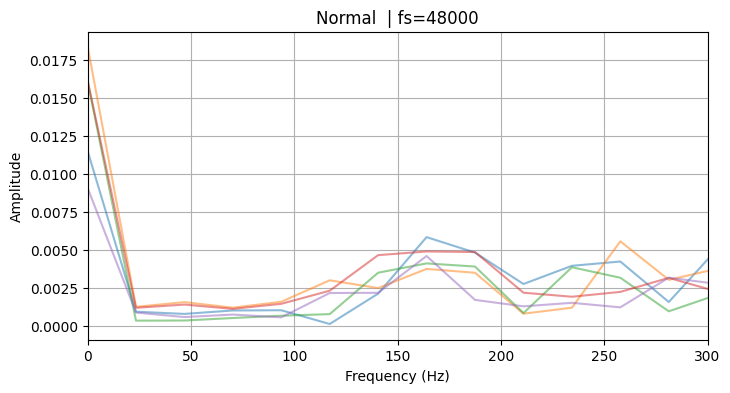

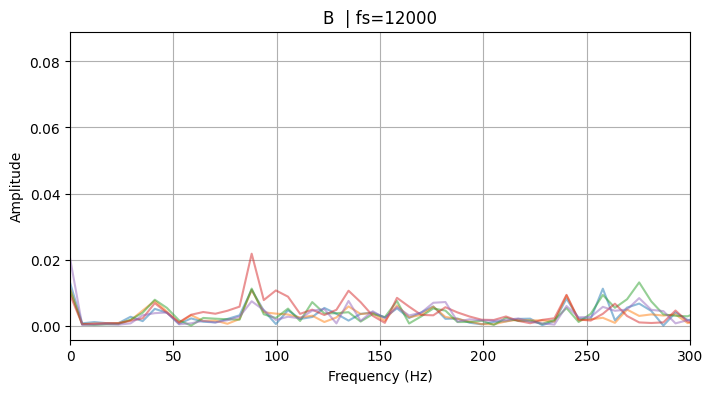

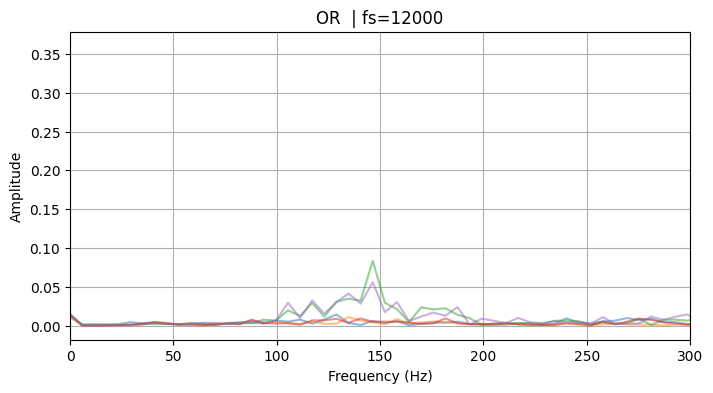

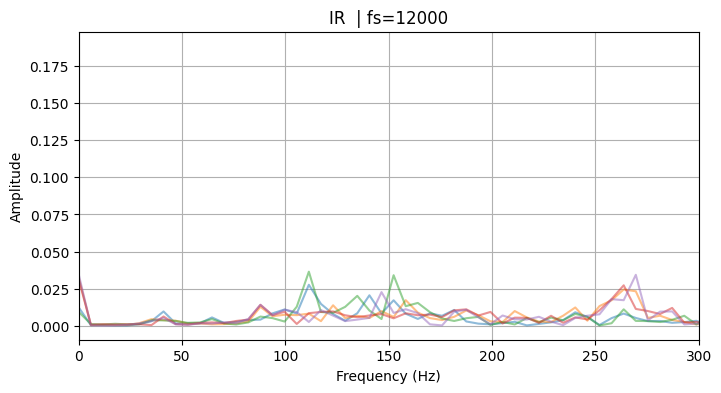

In [24]:
plot_fft_multi("Normal", 48000, n_samples=5) # ~30Hz

plot_fft_multi("B", 12000, n_samples=5) # ~70Hz

plot_fft_multi("OR", 12000, n_samples=5) # ~107Hz

plot_fft_multi("IR", 12000, n_samples=5) # ~160Hz

In [25]:
lengths = {}

for file in mat_files:

    signal = extract_signal_from_mat(file)

    length = len(signal)

    name = os.path.basename(file)

    lengths[name] = length


for k, v in lengths.items():
    print(k, " -> ", v)

Time_Normal_1_098.mat  ->  483903
OR021_6_1_239.mat  ->  489125
IR014_1_175.mat  ->  489125
IR007_1_110.mat  ->  486224
IR021_1_214.mat  ->  485063
OR007_6_1_136.mat  ->  486804
B014_1_190.mat  ->  486224
B007_1_123.mat  ->  487384
OR014_6_1_202.mat  ->  484483
B021_1_227.mat  ->  486804
